# 01 · Framework validation -- CIFAR-100, 9 methods, untrained stand-in backbones

**This batch is framework validation only, never a method comparison.**
Every run uses a tiny randomly-initialized backbone (no pretraining, no
real feature learning), so accuracies sit at or near chance
(1/100 = 0.01 for a 100-class stream). The only question this batch
answers is: *does the harness run every (method x scenario x seed)
combination to completion and produce finite, well-formed metrics?* Any
figure from this batch must carry the "framework validation (untrained
stand-in backbones)" label -- see `b01_cifar224_simplecil_vitb16` for the
scientifically meaningful numbers (real pretrained ViT-B/16).


In [1]:
import sys; sys.path.insert(0, '../..')
from core import loader, viz
viz.set_style()
BATCH = next(b for b in loader.discover_batches('../..') if b.name == 'b02_cifar100_matrix_full')
df = loader.load_per_task(BATCH)
print(BATCH.name, '|', len(df), 'per-task rows |',
      df[['method','scenario','seed']].drop_duplicates().shape[0], 'runs done')

b02_cifar100_matrix_full | 13608 per-task rows | 189 runs done


In [2]:
METHOD_ORDER = ['simplecil', 'ranpac', 'ease', 'aper_adapter', 'tuna',
                'mos', 'coda_prompt', 'dualprompt', 'l2p']
SCENARIO_ORDER = ['disjoint_baseline', 'distribution_shift', 'cumulative_drift',
                  'exact_replay', 'partial_overlap', 'mid_range_revisit', 'long_range_revisit']
N_SEEDS = 3

### Completeness: 189/189 runs done
9 methods x 7 scenarios x 3 seeds = 189 expected runs.

In [3]:
n_runs = df[['method','scenario','seed']].drop_duplicates().shape[0]
expected = len(METHOD_ORDER) * len(SCENARIO_ORDER) * N_SEEDS
print(f'{n_runs}/{expected} runs done')
assert n_runs == expected == 189, 'incomplete matrix -- debug before treating this batch as validated'
print('PASS')

189/189 runs done
PASS


saved D:\Dev\Research\clover-cl\analysis\batches\b02_cifar100_matrix_full\figures\completeness_heatmap.png  +  .pdf


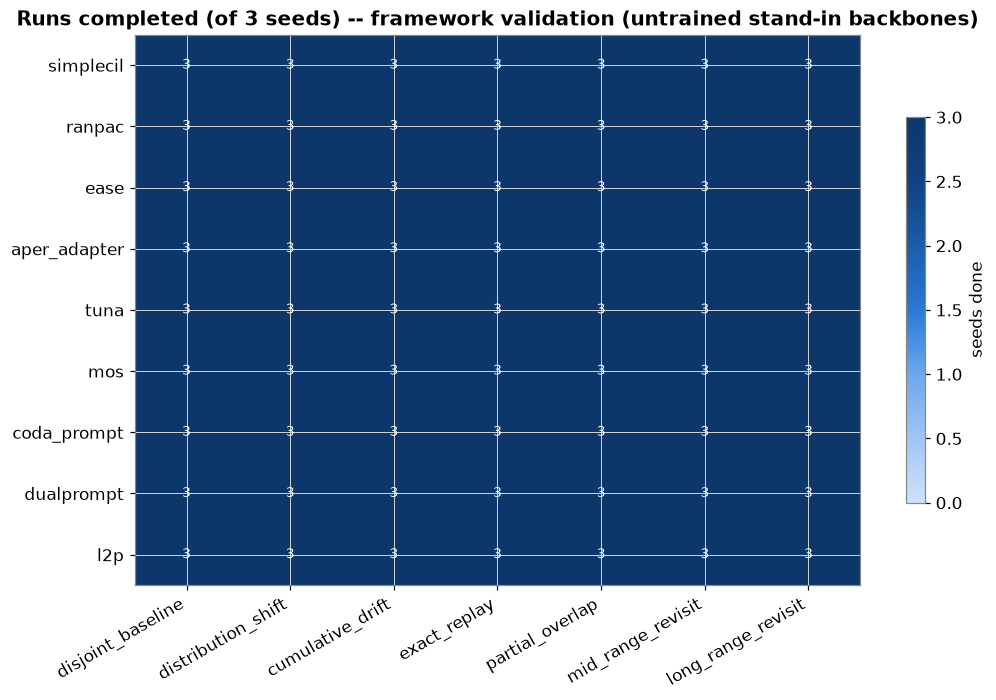

In [4]:
counts = (df[['method','scenario','seed']].drop_duplicates()
          .groupby(['method','scenario'], observed=True).size().unstack('scenario'))
fig = viz.fig_completeness_heatmap(counts, METHOD_ORDER, SCENARIO_ORDER)
viz.save_fig(fig, BATCH.path / 'figures', 'completeness_heatmap')

### Finite metrics per method
`A_t` and `AIA` must be finite and non-null at every run's final task -- a silent NaN here would mean a method crashed or produced degenerate output without tripping `state=='done'`.

In [5]:
final_at = viz.final_task_per_seed(df, 'A_t', ['method'])
finite_counts = (df[df.metric=='A_t']
    .loc[df[df.metric=='A_t'].groupby(['method','scenario','seed'])['task_idx'].idxmax()]
    .groupby('method', observed=True)['value'].apply(lambda s: s.notna().sum()))
check = final_at.set_index('method').reindex(METHOD_ORDER).assign(
    finite_runs=finite_counts.reindex(METHOD_ORDER).to_numpy(),
    expected_runs=len(SCENARIO_ORDER) * N_SEEDS)
display(check[['finite_runs', 'expected_runs', 'mean', 'sem']].round(4))
assert (check['finite_runs'] == check['expected_runs']).all(), 'a method has non-finite A_t somewhere'
print('PASS -- every method has finite A_t at every run\'s final task')

,finite_runs,expected_runs,mean,sem
method,,,,
simplecil,21,21,0.0435,0.0011
ranpac,21,21,0.0823,0.0017
ease,21,21,0.0470,0.0011
aper_adapter,21,21,0.0495,0.0012
tuna,21,21,0.0440,0.0020
mos,21,21,0.0483,0.0013
coda_prompt,21,21,0.0360,0.0027
dualprompt,21,21,0.0353,0.0025
l2p,21,21,0.0362,0.0026


PASS -- every method has finite A_t at every run's final task


### Chance-level framing
Final `A_t` per method, with the 1/100 chance line. These bars must **never** be read as "which method is better" -- with an untrained backbone there is no learned representation for any method to exploit, so differences here reflect only tiny sampling/initialization noise around chance, not a real performance ranking.

saved D:\Dev\Research\clover-cl\analysis\batches\b02_cifar100_matrix_full\figures\final_at_by_method_chance_framing.png  +  .pdf


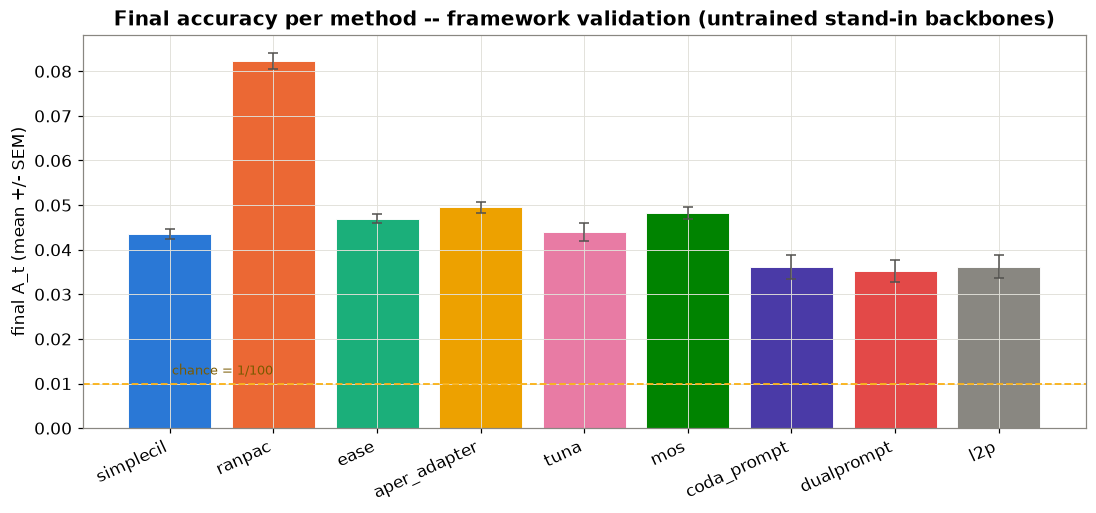

In [6]:
import matplotlib.pyplot as plt
fig = viz.fig_bar_by_group(final_at, 'method', METHOD_ORDER,
    'final A_t (mean +/- SEM)',
    'Final accuracy per method -- framework validation (untrained stand-in backbones)')
fig.axes[0].axhline(0.01, ls='--', lw=1.2, color=viz.STATUS['warning'])
fig.axes[0].text(0.02, 0.012, 'chance = 1/100', fontsize=8.5, color='#7a5a00')
viz.save_fig(fig, BATCH.path / 'figures', 'final_at_by_method_chance_framing')

### Takeaway
189/189 runs done, every method's final-task metrics are finite, and every method sits within a few hundredths of chance -- exactly what a correctly-wired harness with an untrained backbone should produce. This batch validates the framework; `b01` carries the science.